In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('all_stocks_5yr.csv')

print(f" Shape : {df.shape}")
print(f"\n Columns : {df.columns.tolist()}")
print(f"\n Top 5 rows : ")
df.head(5)

 Shape : (619040, 7)

 Columns : ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

 Top 5 rows : 


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [2]:
df.groupby('Name').size()
df.groupby('Name')['volume'].sum()
df1 = df[df['Name']=='AAL']
df1

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
1254,2018-02-01,54.00,54.64,53.59,53.88,3623078,AAL
1255,2018-02-02,53.49,53.99,52.03,52.10,5109361,AAL
1256,2018-02-05,51.99,52.39,49.75,49.76,6878284,AAL
1257,2018-02-06,49.32,51.50,48.79,51.18,6782480,AAL


In [3]:
df['Name'].unique() # شرکت های منحصربفرد
len(df['Name'].unique()) # تعداد شرکت های منحصربفرد
df['Name'].value_counts() # تعداد سطرهای دیتای هر شرکت
min(df['Name'].value_counts()) 

44

In [4]:
df['Name'].nunique() # تعداد شرکت های منحصربفرد

505

In [5]:
df2 = df[df['Name']=='AAPL'].copy()
df2

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
2513,2018-02-01,167.1650,168.6200,166.7600,167.7800,47230787,AAPL
2514,2018-02-02,166.0000,166.8000,160.1000,160.5000,86593825,AAPL
2515,2018-02-05,159.1000,163.8800,156.0000,156.4900,72738522,AAPL
2516,2018-02-06,154.8300,163.7200,154.0000,163.0300,68243838,AAPL


In [6]:
df2['close'].mean()

np.float64(109.06669849086578)

In [7]:
df[df['Name']=='AAPL']['close'].mean()

np.float64(109.06669849086578)

In [8]:
df2['close'].max()

179.26

In [9]:
df2['close'].idxmax()

np.int64(2503)

In [10]:
#پیدا کردن بالاترین قیمت و تاریخ محصولات شرکت اپل
max_price = df2['close'].max()
print("max price : ", max_price)

# ردیفی که بیشترین قیمت رو داره index
max_index = df2['close'].idxmax()
print("index : ", max_index)

# نمایش کل ردیف 
print(df2.loc[[max_index]])

#df2.loc[max_index]    # یه Series — نمایش عمودی (ستون به ستون)
#df2.loc[[max_index]]  # یه DataFrame — نمایش جدولی افقی (چون [max_index] رو داخل لیست گذاشتیم)

max price :  179.26
index :  2503
            date    open   high     low   close    volume  Name
2503  2018-01-18  179.37  180.1  178.25  179.26  31193352  AAPL


In [11]:
type('date')

str

type e jadid e date :  <class 'pandas.core.series.Series'>


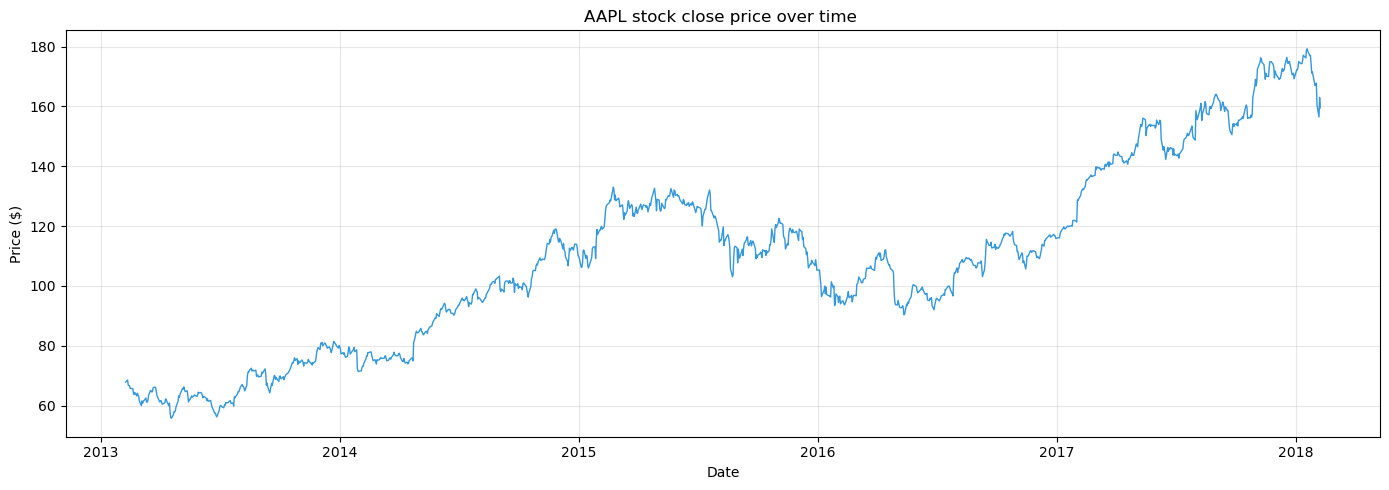

In [12]:
# رسم نمودار خطی از روند قیمت close در طول زمان

# تبدیل تاریخ به فرمت تاریخ واقعی
df2['date'] = pd.to_datetime(df2['date'])
print("type e jadid e date : ", type(df2['date']))

# رسم نمودار 
plt.figure(figsize=(14,5))
plt.plot(df2['date'], df2['close'], color = '#3498db', linewidth = 1)
plt.title('AAPL stock close price over time ')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aapl_price_trend.png', dpi=150)
plt.show()

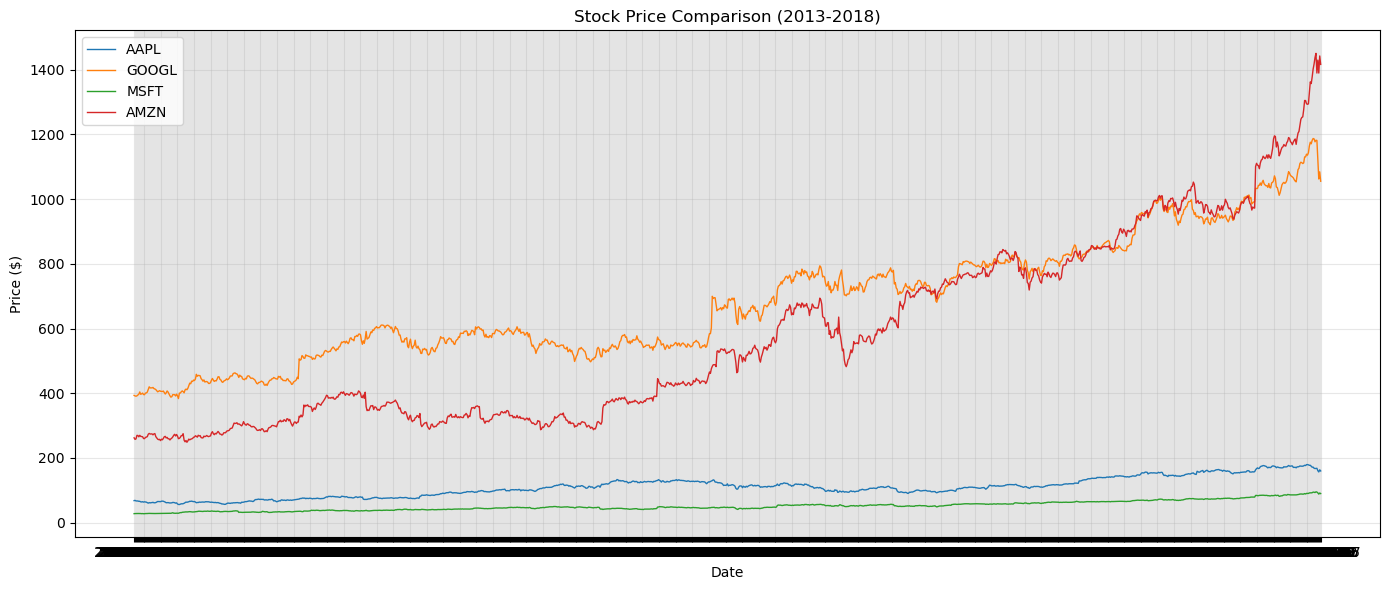

In [13]:
# مقایسه چند شرکت 
companies = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']
plt.figure(figsize=(14,6))

for company in companies:
    temp = df[df['Name']==company].copy()
    temp['Date'] = pd.to_datetime(temp['date'])
    plt.plot(temp['date'], temp['close'], label=company, linewidth=1)

plt.title('Stock Price Comparison (2013-2018)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()  # نشان دهنده ی راهنمای رنگها
plt.grid(True, alpha=0.3)  #رنگ شطرنجی 0.3 خیلی تیره نیست
plt.tight_layout() # تنظیم فاصله ها
plt.savefig('stock_comparison.png', dpi=150)
plt.show()

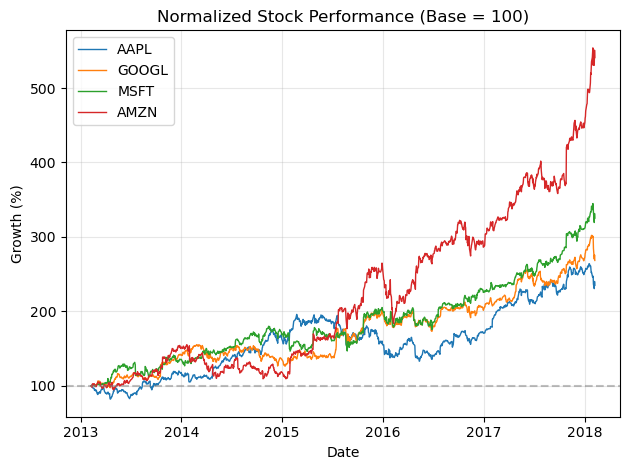

In [14]:
# نرمال سازی برای مقایسه درست قیمت ها 
for company in companies:
    temp = df[df['Name']==company].copy()
    temp['date'] = pd.to_datetime(temp['date'])
    normalized = (temp['close']/temp['close'].iloc[0]) *100 # نرمال‌سازی — همه از ۱۰۰ شروع کنن تا رشد درصدی مقایسه شه
    plt.plot(temp['date'], normalized, label=company, linewidth=1)

plt.title('Normalized Stock Performance (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('stock_normalized.png', dpi=150)
plt.show()
    


In [23]:
# Statistical Summary

print("--- AAPL Statistics  (2013-2018) ---")
print(f"Starting Price : ${df2['close'].iloc[0]:.2f}")
print(f"Ending Price   : ${df2['close'].iloc[-1]:.2f}")
print(f"Total growth   : {((df2['close'].iloc[-1]/df2['close'].iloc[0])-1)*100:.2f}% ")
print(f"Highest Price  : ${df2['close'].max():.2f}")
print(f"Lowest Price   : ${df2['close'].min():.2f}")
print(f"Avg Volume     : {df2['volume'].mean():,.0f}")

--- AAPL Statistics  (2013-2018) ---
Starting Price : $67.85
Ending Price   : $159.54
Total growth   : 135.12% 
Highest Price  : $179.26
Lowest Price   : $55.79
Avg Volume     : 54,047,900


In [32]:
# Final Summary

print("-" *20 , " STOCK MARKET ANALYSIS SUMMARY" ,"-" *20 )
print(f"\n Dataset : ")
print(f" Total records    : {len(df):,} ")
print(f" Unique companies : {df['Name'].nunique()}")
print(f" Data range       : 2013 - 2018 ")
print(f" \n AAPL Performance :")
print(f" Growth           : {((df2['close'].iloc[-1]/df2['close'].iloc[0])-1)*100:.2f}% ")
print(f" All-time high    : ${df2['close'].max():.2f} on {df2.loc[df2['close'].idxmax(), 'date']} ")
print(f" \n Key Findings :  ")
print(f" 1. Tech stocks (AAPL, GOOGL, AMZN, MSFT) all show strong upward trends ")
print(f" 2. AMZN and GOOGL had highest absolute prices but similar growth patterns ")
print(f" 3. Normalization is essential when comparing stocks with different price scales ")
print(f"\n Next Steps:")
print(f"   - Predict future prices with regression models")
print(f"   - Calculate moving averages and volatility")
print(f"   -l Build a simple trading signal model")

--------------------  STOCK MARKET ANALYSIS SUMMARY --------------------

 Dataset : 
 Total records    : 619,040 
 Unique companies : 505
 Data range       : 2013 - 2018 
 
 AAPL Performance :
 Growth           : 135.12% 
 All-time high    : $179.26 on 2018-01-18 00:00:00 
 
 Key Findings :  
 1. Tech stocks (AAPL, GOOGL, AMZN, MSFT) all show strong upward trends 
 2. AMZN and GOOGL had highest absolute prices but similar growth patterns 
 3. Normalization is essential when comparing stocks with different price scales 

 Next Steps:
   - Predict future prices with regression models
   - Calculate moving averages and volatility
   - Build a simple trading signal model
